In [1]:
# importing the essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load the dataset
df = pd.read_csv('../data/bigsales.csv')

In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
print("Shape of the dataset", df.shape)

Shape of the dataset (8523, 12)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [7]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

- The dataset contains null values in the `Item_Weight` and `Outlet_Size` features. 

In [8]:
print(df.duplicated().sum())

0


- There are no duplicate values.

In [9]:
cate_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [10]:
print("Unique values of categorial features:")
print("\n")
for col in cate_cols:
    print(f"{col} | {df[col].unique()}")
    print("----" * 25)

Unique values of categorial features:


Item_Identifier | ['FDA15' 'DRC01' 'FDN15' ... 'NCF55' 'NCW30' 'NCW05']
----------------------------------------------------------------------------------------------------
Item_Fat_Content | ['Low Fat' 'Regular' 'low fat' 'LF' 'reg']
----------------------------------------------------------------------------------------------------
Item_Type | ['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']
----------------------------------------------------------------------------------------------------
Outlet_Identifier | ['OUT049' 'OUT018' 'OUT010' 'OUT013' 'OUT027' 'OUT045' 'OUT017' 'OUT046'
 'OUT035' 'OUT019']
----------------------------------------------------------------------------------------------------
Outlet_Size | ['Medium' nan 'High' 'Small']
---------------------------------------

In [11]:
df[df.Item_Visibility == 0][['Item_Visibility','Item_Outlet_Sales']].head(2)

,Item_Visibility,Item_Outlet_Sales
3,0.0,732.3800
4,0.0,994.7052


- In the dataset:
- The minimum value of `Item_Visibility` is 0, but if an item is being sold in the store, its visibility should not be zero. This suggests that those values are missing values. So we are placing 0.0 values with nan values.

- The `Item_Fat_Content` feature contains inconsistent values. For example, Low fat appears as 'Low Fat', 'low fat', and 'LF', while Regular appears as 'Regular' and 'reg', so this needs to be handled.

- Extracting the ID from the `Item_Identifier` feature, where 'FD' stands for 'Food', 'DR' stands for 'Drink' and 'NC' means the item is not consumable, such as household items, so we are replacing those IDs with 'Non-Edible'.

In [12]:
def clean_data(data):
    data['Item_Identifier'] = data['Item_Identifier'].str[:2].replace({"NC": "Non-Edible"})
    data['Item_Fat_Content'] = data['Item_Fat_Content'].replace({'low fat':'Low Fat', 
                                          'LF' : 'Low Fat',
                                          'reg':'Regular'}) 
    data['Item_Visibility'] = data['Item_Visibility'].replace({0.0: np.nan})

    return data

In [13]:
df = clean_data(df)

In [14]:
print(df['Item_Visibility'].isna().sum())

526


### EDA

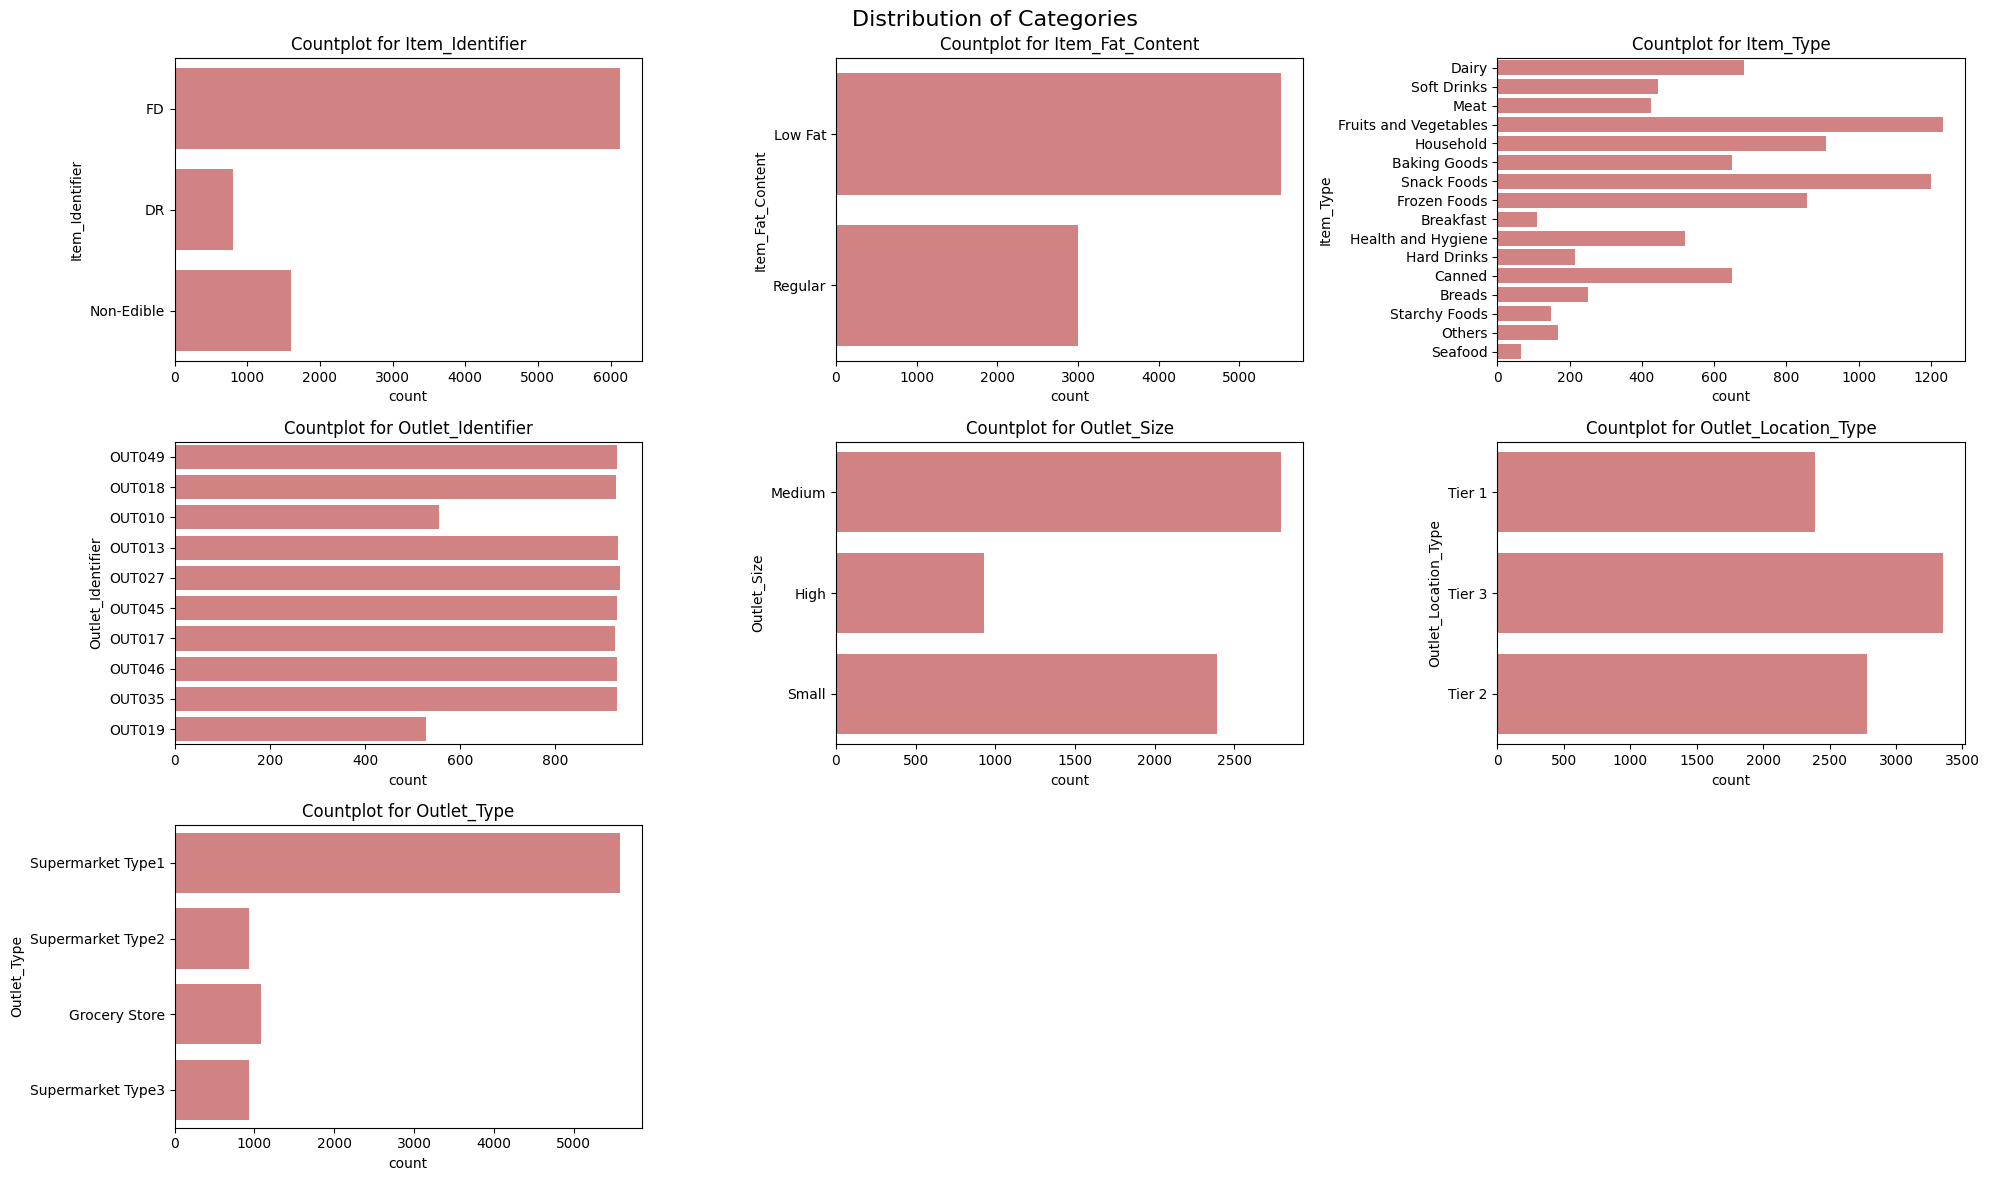

In [15]:
fig, axs = plt.subplots(3, 3, figsize=(20, 12))

axs = axs.flatten()
for i, col in enumerate(cate_cols):
    sns.countplot(df[col], ax=axs[i], color='#de7676')
    axs[i].set_title(f"Countplot for {col}")

for j in range(i+1, len(axs)):
    axs[j].set_axis_off()
    
plt.suptitle("Distribution of Categories", fontsize=16)
plt.tight_layout()
plt.show() 

- Most items belong to the `FD` ID (food category), followed by `Non-edible`.
- The dataset contains more `Low Fat` items than `Regular` items.
- Most items fall under the `Fruits and Vegetables` type, followed by `Snack Foods` and `Household`.
- Outlets with IDs `OUT010` and `OUT019` are less represented than the other outlets.
- Mostly outlets are medium-sized, followed by small and high.
- Most outlets are located in `Tier 3` cities, followed by `Tier 2` and `Tier 1`.
- Most outlets are of type `Supermarket Type1`, followed by `Grocery Store`.

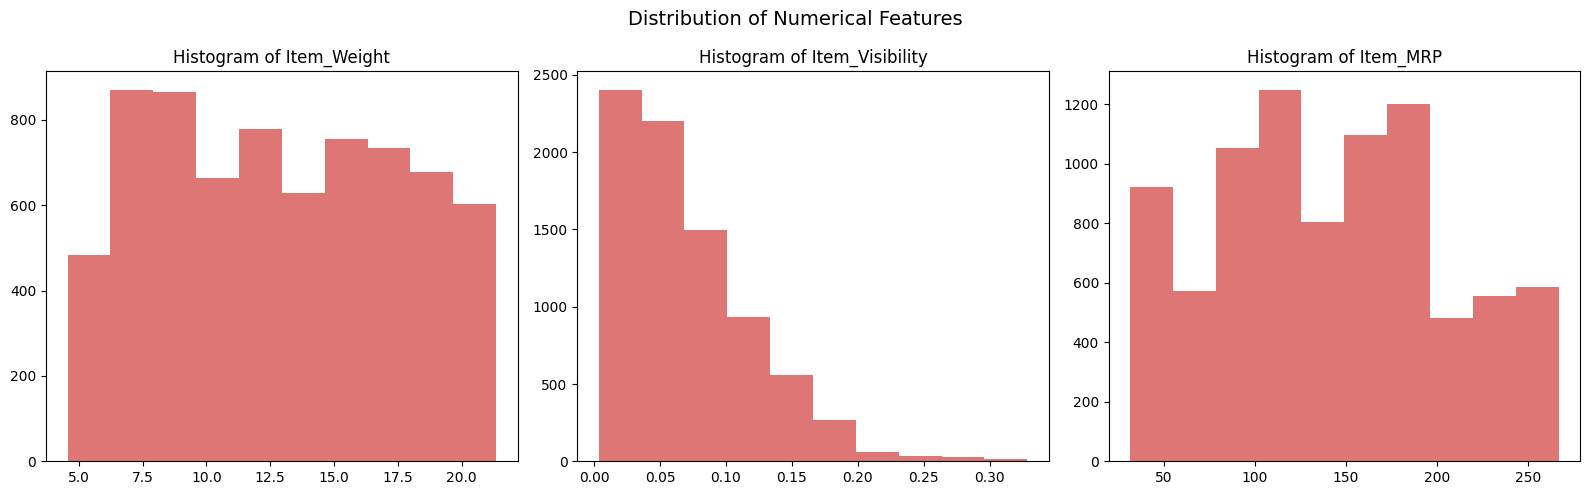

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

axs = axs.flatten()

for i, col in enumerate(num_cols[:3]):
    axs[i].hist(df[col], color='#de7676')
    axs[i].set_title(f"Histogram of {col}")

plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

- `Item_Weight` and `Item_MRP` are approximately normally distributed.
- `Item_Visibility` is highly right-skewed. 

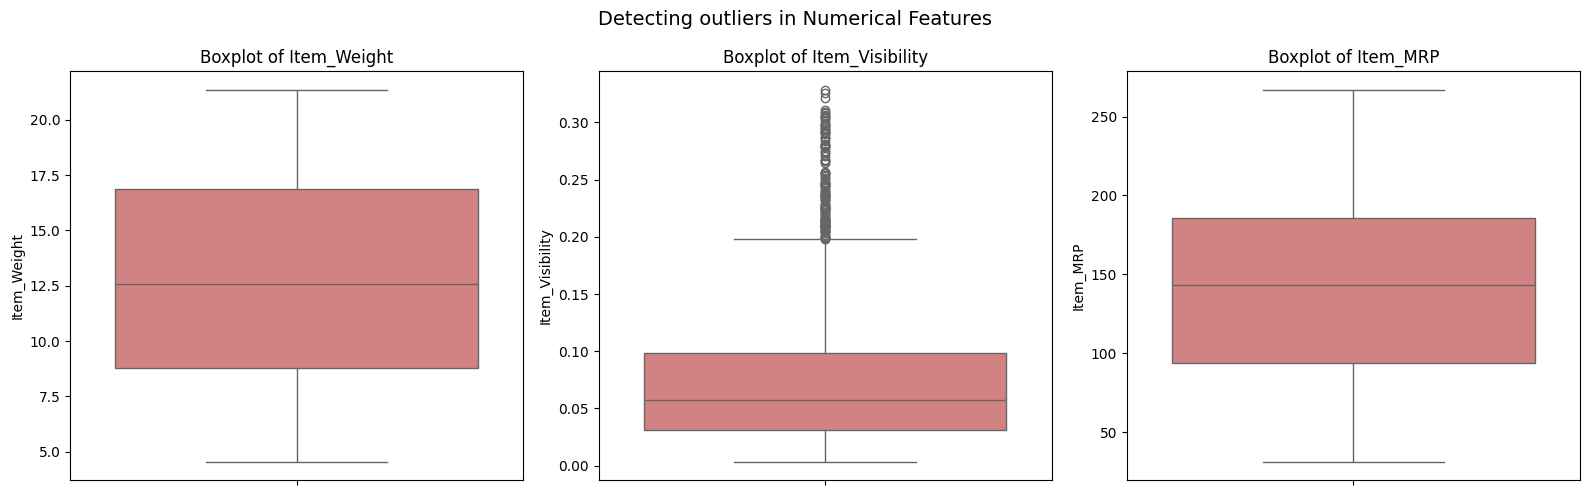

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

axs = axs.flatten()

for i, col in enumerate(num_cols[:3]):
    sns.boxplot(df[col], ax=axs[i], color='#de7676')
    axs[i].set_title(f"Boxplot of {col}")

plt.suptitle("Detecting outliers in Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

- `Item_Visibility` contains high-value outliers. 

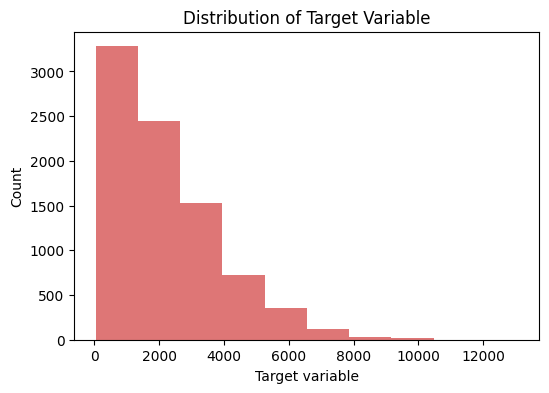

In [18]:
plt.figure(figsize=(6,4))

plt.hist(df['Item_Outlet_Sales'], color = '#de7676')
plt.title("Distribution of Target Variable")
plt.xlabel("Target variable")
plt.ylabel("Count")
plt.show()

- Target variable is highly right-skewed.

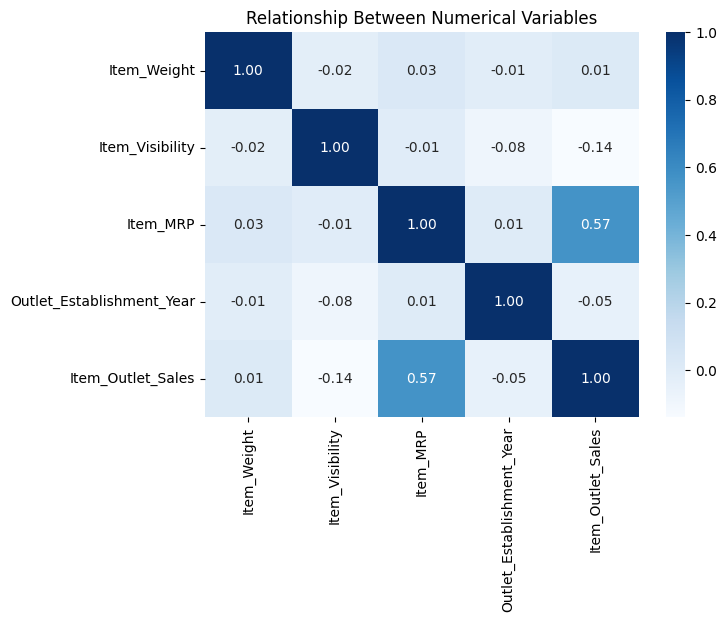

In [19]:
plt.figure(figsize=(7,5))
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')
plt.title("Relationship Between Numerical Variables")
plt.show()

- From the heatmap, we can conclude that `Item_MRP` is positively correlated with the target variable `Item_Outlet_Sales`.

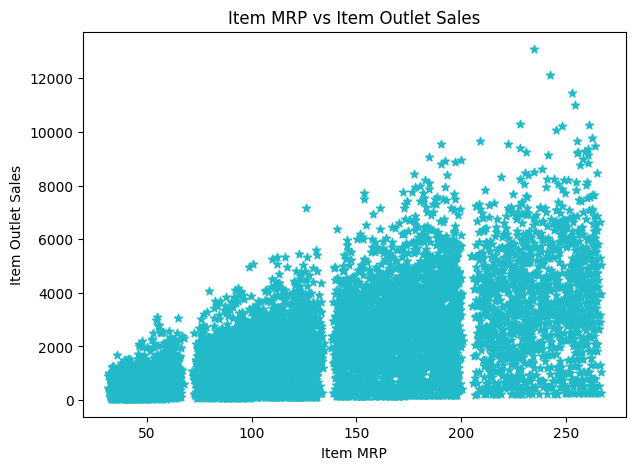

In [20]:
plt.figure(figsize=(7,5))
plt.scatter(df['Item_MRP'], df['Item_Outlet_Sales'], color = '#22bac9', marker="*")
plt.title("Item MRP vs Item Outlet Sales")
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")
plt.show()

- From the plot above, we can conclude that costly items show both higher and lower sales. Only a few costly items have high sales, likely those belonging to a specific category.

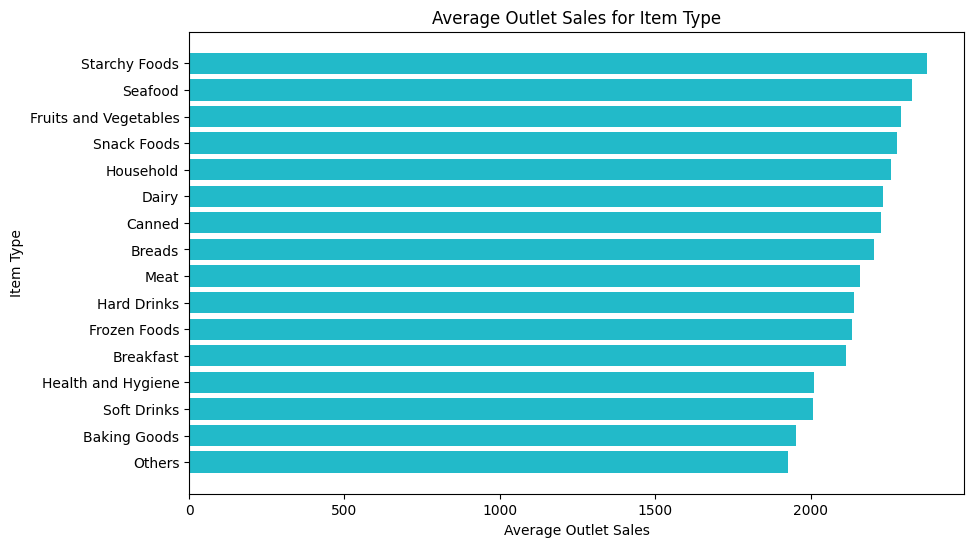

In [21]:
# which items generate more sales?

avg_sales_by_item = df.groupby("Item_Type", as_index=False)['Item_Outlet_Sales'].mean().sort_values(by ='Item_Outlet_Sales')

plt.figure(figsize=(10,6))
plt.barh(avg_sales_by_item.Item_Type, avg_sales_by_item.Item_Outlet_Sales, color= '#22bac9')
plt.title("Average Outlet Sales for Item Type")
plt.xlabel("Average Outlet Sales")
plt.ylabel("Item Type")
plt.show()

- Average sales are higher for `Starchy Foods`, followed by `Seafood` and `Fruits and Vegetables`. 

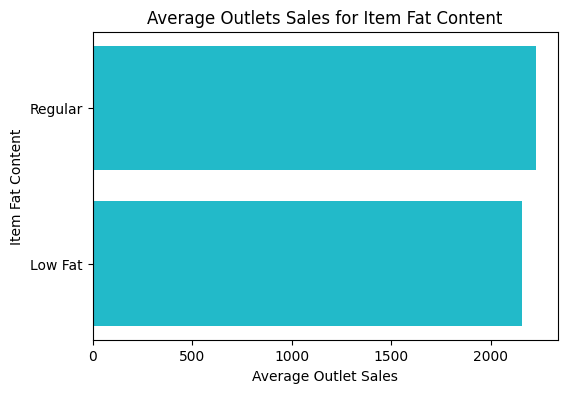

In [22]:
# do low-fat items generate more sales?
avg_sales_item_fat = df.groupby(by = 'Item_Fat_Content', as_index=False)['Item_Outlet_Sales'].mean()

plt.figure(figsize=(6,4))
plt.barh(avg_sales_item_fat.Item_Fat_Content, avg_sales_item_fat.Item_Outlet_Sales, color= '#22bac9')
plt.title("Average Outlets Sales for Item Fat Content")
plt.xlabel("Average Outlet Sales")
plt.ylabel("Item Fat Content")
plt.show()

- `Regular` items generate slightly more sales than `Low Fat` items.

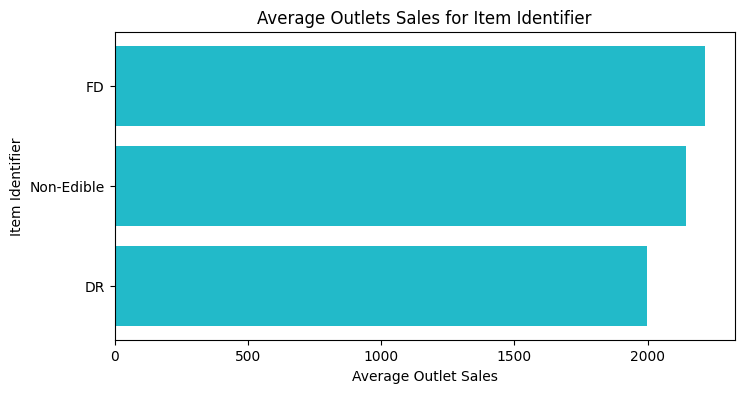

In [23]:
# What kind of item generates more sales?

avg_sales_item_id = df.groupby("Item_Identifier", as_index=False)["Item_Outlet_Sales"].mean().sort_values(by='Item_Outlet_Sales')

plt.figure(figsize=(8,4))
plt.barh(avg_sales_item_id.Item_Identifier, avg_sales_item_id.Item_Outlet_Sales, color= '#22bac9')
plt.title("Average Outlets Sales for Item Identifier")
plt.xlabel("Average Outlet Sales")
plt.ylabel("Item Identifier")
plt.show()

- Items with `FD` ID generate more sales, followed by `NC` and `DR`.

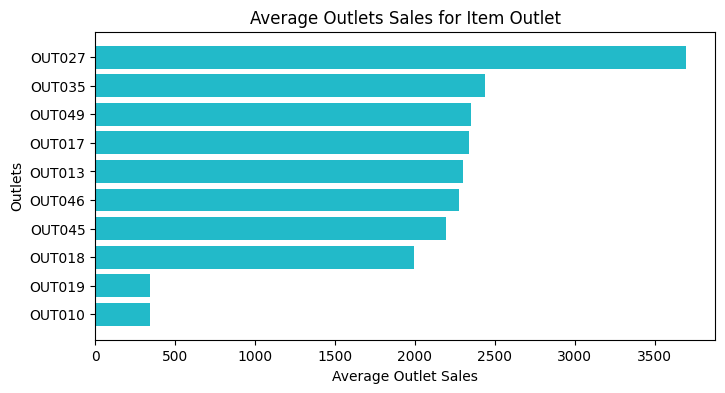

In [24]:
# which outlet generates more sales

outlet_avg_sales = df.groupby(by=['Outlet_Identifier'], as_index=False)['Item_Outlet_Sales'].mean().sort_values(by='Item_Outlet_Sales')

plt.figure(figsize=(8,4))
plt.barh(outlet_avg_sales['Outlet_Identifier'], outlet_avg_sales['Item_Outlet_Sales'], color= '#22bac9')
plt.title("Average Outlets Sales for Item Outlet")
plt.xlabel("Average Outlet Sales")
plt.ylabel("Outlets")
plt.show()

- Outlet with ID `OUT027` generates more sales, followed by `OUT035`.

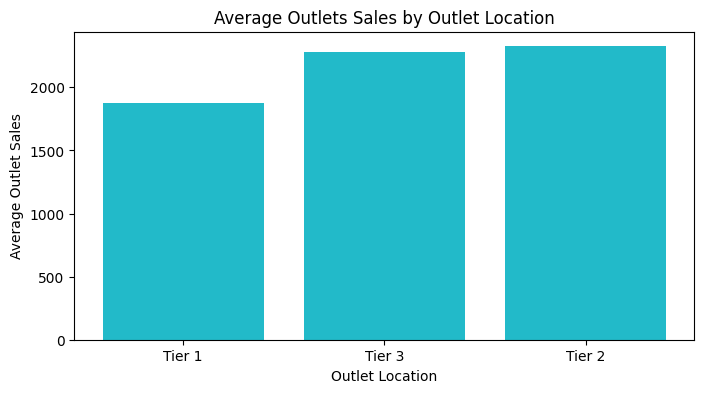

In [25]:
# average sales by outlet location
avg_sales_loc = df.groupby(by=['Outlet_Location_Type'], as_index=False)['Item_Outlet_Sales'].mean().sort_values(by='Item_Outlet_Sales') 

plt.figure(figsize=(8,4))
plt.bar(avg_sales_loc['Outlet_Location_Type'], avg_sales_loc['Item_Outlet_Sales'], color= '#22bac9')
plt.title("Average Outlets Sales by Outlet Location")
plt.xlabel("Outlet Location")
plt.ylabel("Average Outlet Sales")
plt.show()

- Outlets in `Tier 2` and `Tier 3` cities are generating approximately equal average sales, which are higher overall.

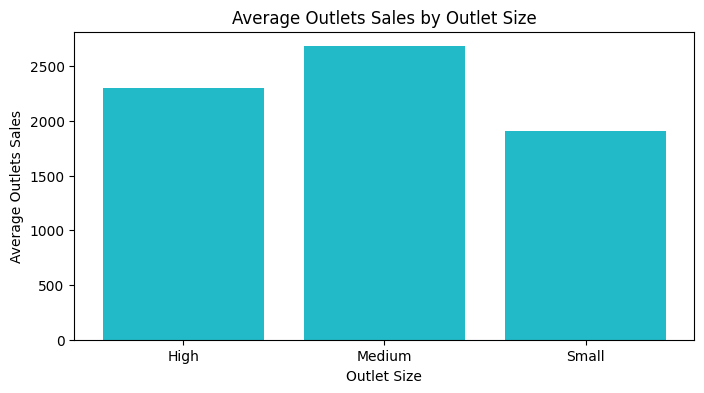

In [26]:
# average outlet sales by outlet size
avg_sales_by_size = df.groupby(by = 'Outlet_Size', as_index=False)['Item_Outlet_Sales'].mean()

plt.figure(figsize=(8,4))
plt.bar(avg_sales_by_size['Outlet_Size'], avg_sales_by_size['Item_Outlet_Sales'], color= '#22bac9')
plt.title("Average Outlets Sales by Outlet Size")
plt.xlabel("Outlet Size")
plt.ylabel("Average Outlets Sales")
plt.show()

- Medium-sized outlets generate more sales, followed by high- and small-sized outlets.

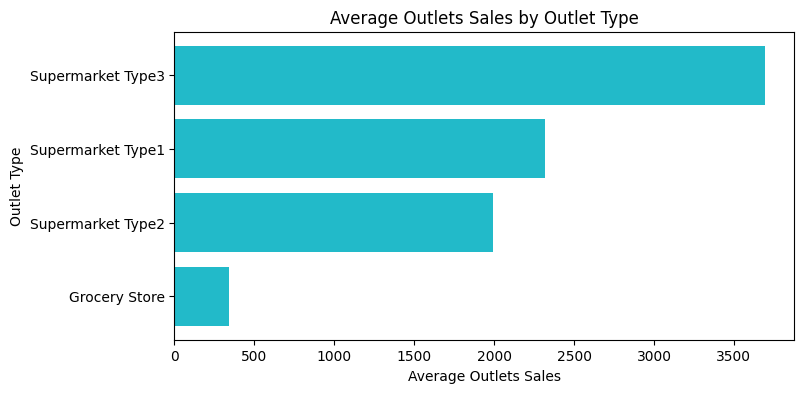

In [27]:
# how outlet types influence average sales

avg_sales_by_type = df.groupby(by='Outlet_Type', as_index=False)['Item_Outlet_Sales'].mean().sort_values(by='Item_Outlet_Sales')

plt.figure(figsize=(8,4))
plt.barh(avg_sales_by_type['Outlet_Type'], avg_sales_by_type['Item_Outlet_Sales'], color= '#22bac9')
plt.title("Average Outlets Sales by Outlet Type")
plt.xlabel("Average Outlets Sales")
plt.ylabel("Outlet Type")
plt.show()

- Average sales are highest for `Supermarket Type3`, followed by `Supermarket Type1` and `Supermarket Type2`.
- `Grocery Store` has very little influence on average sales.

In [28]:
df[df['Outlet_Type'] == 'Supermarket Type3']['Outlet_Identifier'].value_counts()

Outlet_Identifier
OUT027    935
Name: count, dtype: int64

In [29]:
df[df['Outlet_Type'] == 'Supermarket Type3']['Outlet_Size'].value_counts()

Outlet_Size
Medium    935
Name: count, dtype: int64

In [30]:
df[df['Outlet_Type'] == 'Supermarket Type3']['Outlet_Location_Type'].value_counts()

Outlet_Location_Type
Tier 3    935
Name: count, dtype: int64

#### `Supermarket Type3` has only one medium-size outlet in Tier-3 cities, with the ID `OUT027`, which alone generates more sales than outlets of any other type or ID.

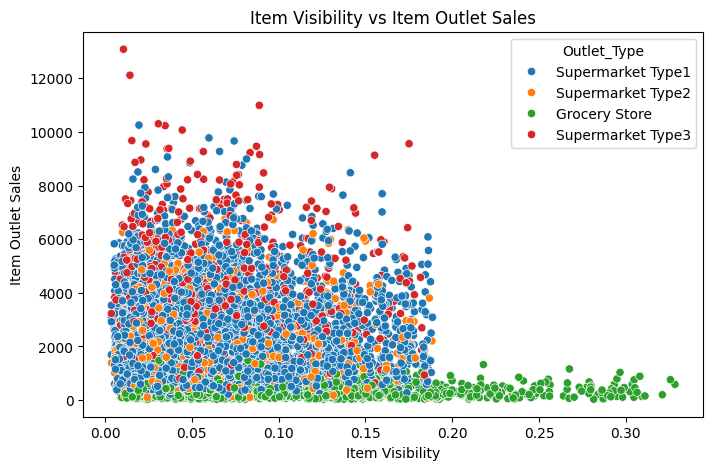

In [31]:
# item visibility vs outlet sales

plt.figure(figsize=(8,5))
sns.scatterplot(df, x = 'Item_Visibility', y= 'Item_Outlet_Sales', hue= 'Outlet_Type')
plt.title("Item Visibility vs Item Outlet Sales")
plt.xlabel("Item Visibility")
plt.ylabel("Item Outlet Sales")
plt.show()

- In the scatterplot above, there is no clear pattern.
- However, the grocery store visibility does not appear to influence sales, whether items are less visible or more visible. 
- Some less visible items generate sales equal to or more than those of more visible items across supermarket types.

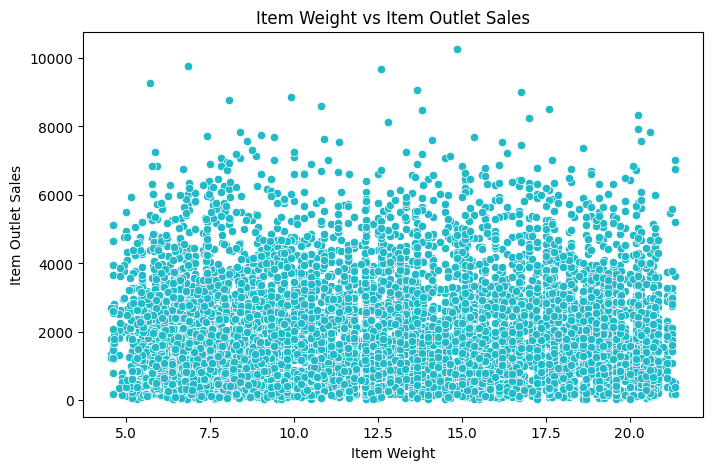

In [32]:
# How item's weight influences sales

plt.figure(figsize=(8,5))
sns.scatterplot(df, x = 'Item_Weight', y= 'Item_Outlet_Sales', color= '#22bac9')
plt.title("Item Weight vs Item Outlet Sales")
plt.xlabel("Item Weight")
plt.ylabel("Item Outlet Sales")
plt.show()

- An item's weight does not influence sales; people tend to buy what they like rather than consider its weight.

### Visualizing the Null values

In [33]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility               526
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

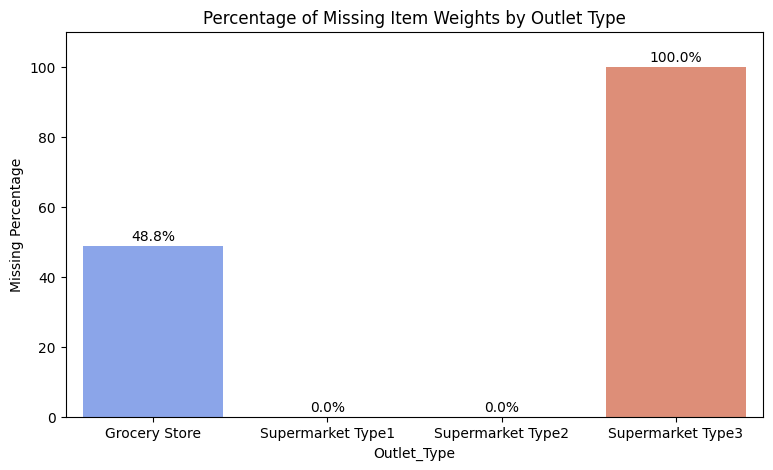

In [34]:
# Plotting the percentage of missing item weight by Outlet Type
per_missing_weight = df.groupby('Outlet_Type')['Item_Weight'].apply(lambda x: x.isnull().mean() * 100).reset_index()

plt.figure(figsize=(9,5))
ax1 = sns.barplot(data= per_missing_weight, x = "Outlet_Type", y= "Item_Weight", palette='coolwarm')

for container in ax1.containers:
    ax1.bar_label(container, fmt="%.1f%%", padding=2)

plt.title("Percentage of Missing Item Weights by Outlet Type")
plt.ylabel("Missing Percentage")
plt.ylim(0,110)
plt.show()

- `Supermarket Type1` and `Supermarket Type2` do not contribute to missing item weights, whereas `Supermarket Type3` has null values in all rows, indicating that it does not record item weights. We can fill those missing values with 0.
- `Grocery Store` has only 48% missing values, so we fill missing values with the mean value of the weights.

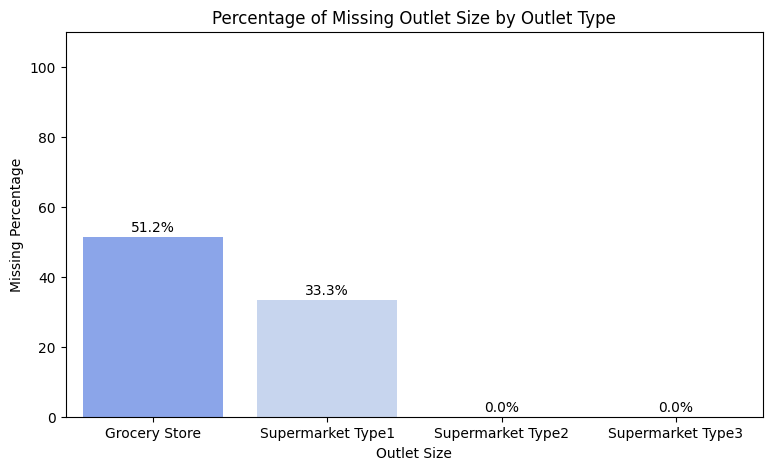

In [35]:
# Plotting the percentage of missing outlet size by Outlet Type
per_missing_size = df.groupby('Outlet_Type')['Outlet_Size'].apply(lambda x: x.isnull().mean() * 100).reset_index()

plt.figure(figsize=(9,5))
ax = sns.barplot(data= per_missing_size, x = "Outlet_Type", y= "Outlet_Size", palette='coolwarm')

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2)

plt.title("Percentage of Missing Outlet Size by Outlet Type")
plt.xlabel("Outlet Size")
plt.ylabel("Missing Percentage")
plt.ylim(0,110)
plt.show()

- `Supermarket Type2` and `Supermarket Type3` do not have any missing outlet size values in any row.
- In contrast, `Grocery Store` has null values in 51% of its total stores, and `Supermarket Type1` has null values in 33% of its total stores. We can fill those null values using mode. 

### Handling missing values

In [36]:
# filling missing values for grocery store
df['Item_Weight'] = np.where((df['Item_Weight'].isnull()) & (df['Outlet_Type'] == 'Grocery Store'), df['Item_Weight'].mean(), df['Item_Weight'])
# filling missing values for supermarket type3
df['Item_Weight'] = df['Item_Weight'].fillna(0)

In [37]:
df.groupby('Outlet_Type')['Outlet_Size'].agg(lambda x: x.mode()[0])

Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: object

- As we can see, both `Grocery Store` and `Supermarket Type1` mode value is 'Small'

In [38]:
df['Outlet_Size'] = df['Outlet_Size'].fillna('Small')

- `Item_Visibility` is highly right-skewed, so for this, we fill missing values using its median value. 

In [39]:
vis_median = df.Item_Visibility.median()
df['Item_Visibility'] = df['Item_Visibility'].fillna(vis_median)

### Handing Outliers

- As we know, `Item_Visibility` is right-skewed and contains high-value outliers, so handling these outliers involves capping them, which means replacing these outliers with the upper bound value derived using the IQR method.

In [40]:
Q1 = df["Item_Visibility"].quantile(0.25)
Q3 = df["Item_Visibility"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("LB: ", lower_bound)
print("UB: ", upper_bound)

LB:  -0.059164579999999994
UB:  0.186835216


In [41]:
df['Item_Visibility'] = np.where(df['Item_Visibility'] > upper_bound, upper_bound, df['Item_Visibility'])

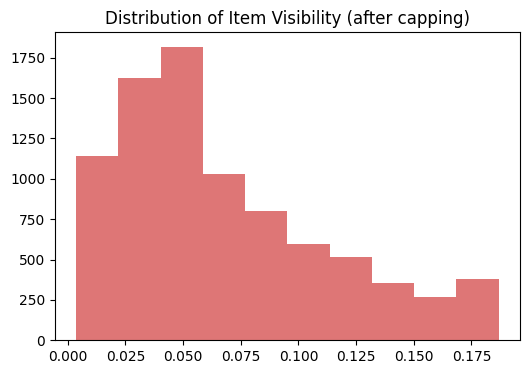

In [42]:
plt.figure(figsize=(6,4))
plt.hist(df['Item_Visibility'], color='#de7676')
plt.title("Distribution of Item Visibility (after capping)")
plt.show()

In [43]:
## Saving the cleaned data
df.to_csv('../data/cleaned_data.csv', index=False)